# Week 7: Model Deployment & Real-World Application
## Housing Price Prediction

### Overview

This notebook focuses on deploying the machine learning model developed during the previous weeks into a reusable real-world application.

The Housing Price Prediction project uses the Gradient Boosting Regressor selected during Week 6 model comparison. The trained model will be saved using Joblib and later integrated into a prediction API and Streamlit web application.

### Objectives

By the end of this notebook, the following tasks will be completed:

1. Load the cleaned housing dataset.
2. Prepare the features and target variable.
3. Recreate the selected machine learning pipeline.
4. Train the Gradient Boosting Regression model.
5. Evaluate the model.
6. Save the trained pipeline using Joblib.
7. Test that the saved model can be loaded successfully.
8. Prepare the model for API and Streamlit deployment.

In [8]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

## 1. Load the Dataset

The cleaned housing dataset generated during the previous stages of the project will be used for deployment.

Using the cleaned dataset ensures that the deployment workflow is based on the same data preparation process used during model development.

In [9]:
housing = pd.read_csv("./../data/cleaned/housing_cleaned.csv")

housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [10]:
print("Dataset shape:", housing.shape)

Dataset shape: (545, 13)


In [11]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [12]:
housing.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## 2. Define Features and Target

The objective of the model is to predict the selling price of a house.

The `price` column is therefore used as the target variable, while the remaining columns are used as predictive features.

In [13]:
X = housing.drop("price", axis=1)
y = housing["price"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("price")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Target:
price

Feature shape: (545, 12)
Target shape: (545,)


## 3. Identify Numerical and Categorical Features

The housing dataset contains both numerical and categorical variables.

Numerical variables can be passed directly to the model, while categorical variables must be converted into numerical representations.

One-Hot Encoding will be applied to categorical variables through a preprocessing pipeline.

In [14]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


## 4. Split the Dataset

The dataset is divided into training and testing subsets.

The training data is used to fit the preprocessing steps and Gradient Boosting model, while the test data is reserved for evaluating how well the final pipeline performs on unseen data.

A `random_state` of 42 is used to ensure reproducibility.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (436, 12)
Testing set: (109, 12)


## 5. Build the Preprocessing Pipeline

To make the model suitable for deployment, preprocessing and model training are combined into a single Scikit-learn Pipeline.

Categorical variables are transformed using One-Hot Encoding.

Using a single pipeline is important for deployment because the exact same transformations applied during training will automatically be applied to new user input.

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features
        )
    ]
)

## 6. Build the Gradient Boosting Model

Gradient Boosting Regressor was selected as the final housing model because it achieved the strongest overall performance during the Week 6 model comparison.

The model combines multiple weak learners sequentially, with each new learner attempting to reduce the errors made by previous learners.

In [17]:
gradient_boosting = GradientBoostingRegressor(
    random_state=42
)

In [18]:
housing_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", gradient_boosting)
    ]
)

## 7. Train the Complete Pipeline

The complete pipeline is trained using the training dataset.

This means that both feature preprocessing and model training are performed together.

In [19]:
housing_pipeline.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## 8. Evaluate the Deployed Model

The trained pipeline is evaluated using the test dataset.

The following regression metrics are calculated:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [20]:
y_pred = housing_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Gradient Boosting Regression Performance")
print("-" * 45)
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

Gradient Boosting Regression Performance
---------------------------------------------
MAE:  967,227.33
RMSE: 1,299,730.23
R²:   0.6658


### Previous Week 6 Benchmark

The Week 6 Gradient Boosting model achieved approximately:

- MAE: 961,734.63
- R²: 0.6650

The current pipeline should produce comparable results because it uses the same cleaned dataset, train/test methodology, and Gradient Boosting approach.

Minor differences may occur if preprocessing or the train/test split differs from the original Week 6 implementation.

## 9. Test a Sample Prediction

Before saving the model, a sample record from the test dataset is passed through the complete pipeline.

This confirms that the pipeline can accept raw feature values and generate a house price prediction.

In [21]:
sample_house = X_test.iloc[[0]]

sample_prediction = housing_pipeline.predict(sample_house)

print("Sample house:")
display(sample_house)

print(f"\nPredicted price: {sample_prediction[0]:,.2f}")
print(f"Actual price:    {y_test.iloc[0]:,.2f}")

Sample house:


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,5900,4,2,2,no,no,yes,no,no,1,no,unfurnished



Predicted price: 4,502,828.37
Actual price:    4,060,000.00


## 10. Save the Trained Model

The complete preprocessing and prediction pipeline is saved using Joblib.

Saving the complete pipeline allows the model to be reused later without retraining. It also ensures that new API or Streamlit inputs undergo the same preprocessing used during model training.

In [22]:
os.makedirs("model", exist_ok=True)

model_path = "model/housing_price_model.joblib"

joblib.dump(
    housing_pipeline,
    model_path
)

print(f"Model saved successfully to: {model_path}")

Model saved successfully to: model/housing_price_model.joblib


In [23]:
print("Model file exists:", os.path.exists(model_path))
print("File size:", os.path.getsize(model_path), "bytes")

Model file exists: True
File size: 143741 bytes


## 11. Test Model Loading

The saved model is loaded from disk to verify that it can be reused independently of the training process.

This simulates what will happen when the API or Streamlit application starts.

In [24]:
loaded_model = joblib.load(model_path)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [25]:
loaded_prediction = loaded_model.predict(sample_house)

print(f"Prediction from loaded model: {loaded_prediction[0]:,.2f}")

Prediction from loaded model: 4,502,828.37


In [26]:
print(
    "Predictions match:",
    np.isclose(sample_prediction[0], loaded_prediction[0])
)

Predictions match: True


## 12. Actual vs Predicted Prices

The following visualization compares actual house prices with the prices predicted by the trained model.

Points closer to the diagonal indicate predictions that are closer to the actual values.

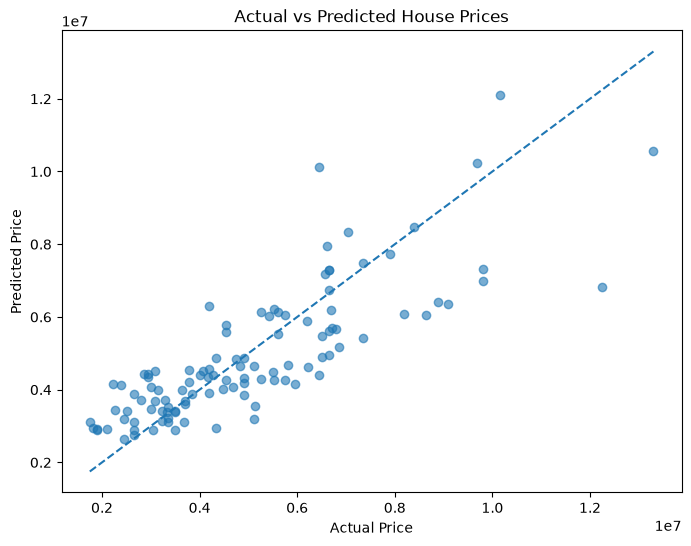

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.show()

## 13. Deployment Preparation Summary

The Housing Price Prediction model has successfully been prepared for deployment.

### Completed Tasks

- Loaded the cleaned housing dataset.
- Defined prediction features and target variable.
- Created a preprocessing pipeline.
- Used One-Hot Encoding for categorical variables.
- Trained a Gradient Boosting Regressor.
- Evaluated model performance.
- Generated sample predictions.
- Saved the complete pipeline using Joblib.
- Successfully reloaded the saved model.
- Verified that the loaded model generates predictions.

### Next Step

The saved `housing_price_model.joblib` file will be integrated into a FastAPI prediction service and a Streamlit user interface.